In [2]:
import pandas as pd

schools = pd.read_csv("schools.csv")

print(schools.head())
print(schools.shape)

                                         school_name  ... percent_tested
0  New Explorations into Science, Technology and ...  ...            NaN
1                               Essex Street Academy  ...           78.9
2                       Lower Manhattan Arts Academy  ...           65.1
3    High School for Dual Language and Asian Studies  ...           95.9
4      Henry Street School for International Studies  ...           59.7

[5 rows x 7 columns]
(375, 7)


In [3]:
math_schools = schools[schools["average_math"]>=640]
best_math_schools_unsrt = math_schools[["school_name","average_math"]]
best_math_schools = best_math_schools_unsrt.sort_values("average_math",ascending=False)
print(best_math_schools)

                                           school_name  average_math
88                              Stuyvesant High School           754
170                       Bronx High School of Science           714
93                 Staten Island Technical High School           711
365  Queens High School for the Sciences at York Co...           701
68   High School for Mathematics, Science, and Engi...           683
280                     Brooklyn Technical High School           682
333                        Townsend Harris High School           680
174  High School of American Studies at Lehman College           669
0    New Explorations into Science, Technology and ...           657
45                       Eleanor Roosevelt High School           641


In [4]:
school_scores = schools[["school_name","average_math","average_reading","average_writing"]]
school_scores["total_SAT"] = school_scores.iloc[:,1:4].sum(axis="columns")
school_scores_srt = school_scores.sort_values("total_SAT",ascending=False)
top_10_schools = school_scores_srt[["school_name","total_SAT"]].iloc[0:10]
print(top_10_schools)

                                           school_name  total_SAT
88                              Stuyvesant High School       2144
170                       Bronx High School of Science       2041
93                 Staten Island Technical High School       2041
174  High School of American Studies at Lehman College       2013
333                        Townsend Harris High School       1981
365  Queens High School for the Sciences at York Co...       1947
5                       Bard High School Early College       1914
280                     Brooklyn Technical High School       1896
45                       Eleanor Roosevelt High School       1889
68   High School for Mathematics, Science, and Engi...       1889


In [5]:
schools["total_SAT"]=schools.iloc[:,3:6].sum(axis="columns")
import numpy as np
standard_devs = schools.pivot_table(values="total_SAT",index="borough",aggfunc=np.std)
print(standard_devs)
Manhattan_borough = schools[schools["borough"]=="Manhattan"]
print(Manhattan_borough)
Manhattan_mean = Manhattan_borough["total_SAT"].mean()
print(Manhattan_mean)
largest_std_dev_1={"borough":["Manhattan"],"num_schools":[89],"average_SAT":[1340.13],"std_SAT":[230.29]}
largest_std_dev=pd.DataFrame(largest_std_dev_1)
print(largest_std_dev)

                total_SAT
borough                  
Bronx          150.393901
Brooklyn       154.868427
Manhattan      230.294140
Queens         195.252899
Staten Island  222.303596
                                          school_name  ... total_SAT
0   New Explorations into Science, Technology and ...  ...      1859
1                                Essex Street Academy  ...      1193
2                        Lower Manhattan Arts Academy  ...      1261
3     High School for Dual Language and Asian Studies  ...      1529
4       Henry Street School for International Studies  ...      1197
..                                                ...  ...       ...
84                Manhattan International High School  ...      1178
85                       Talent Unlimited High School  ...      1479
86                               Vanguard High School  ...      1236
87                     Life Sciences Secondary School  ...      1300
88                             Stuyvesant High School  ... 

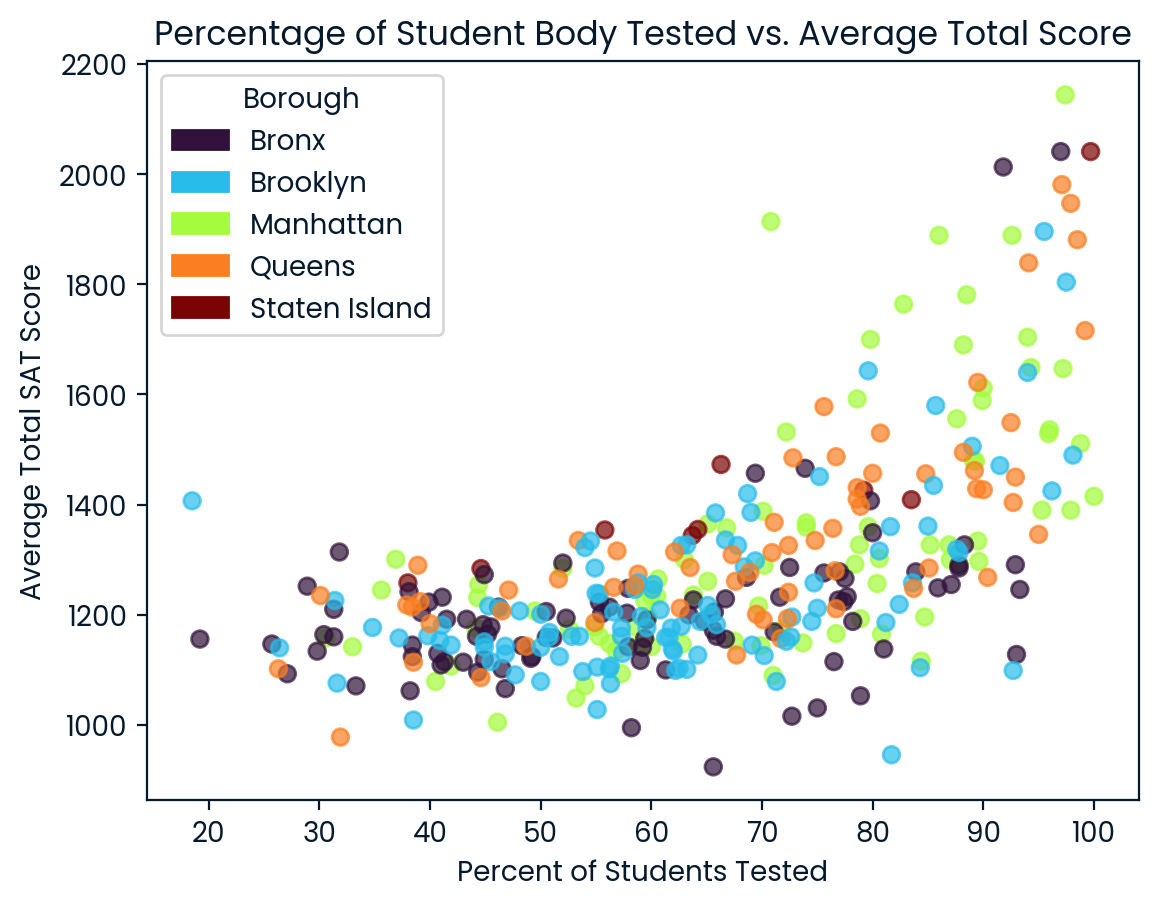

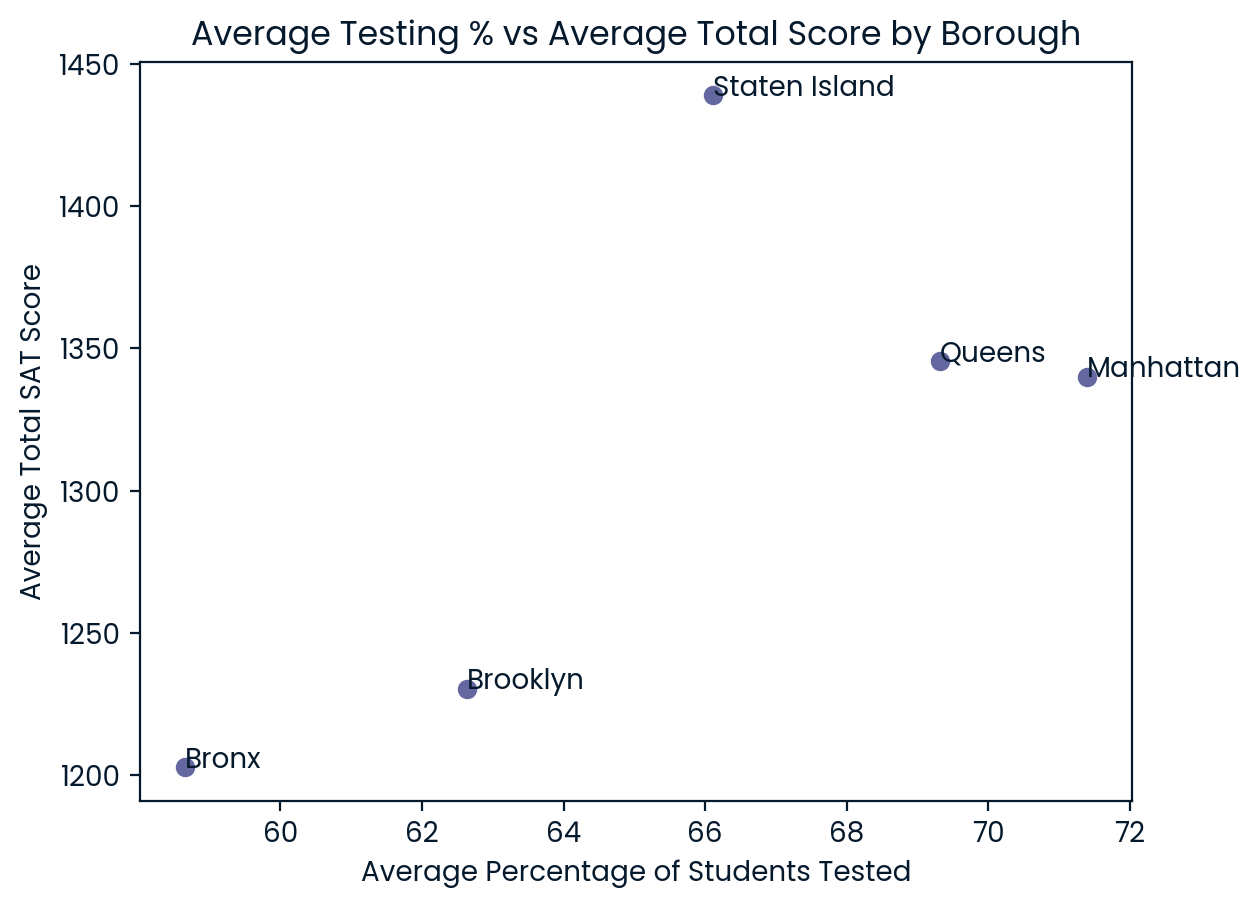

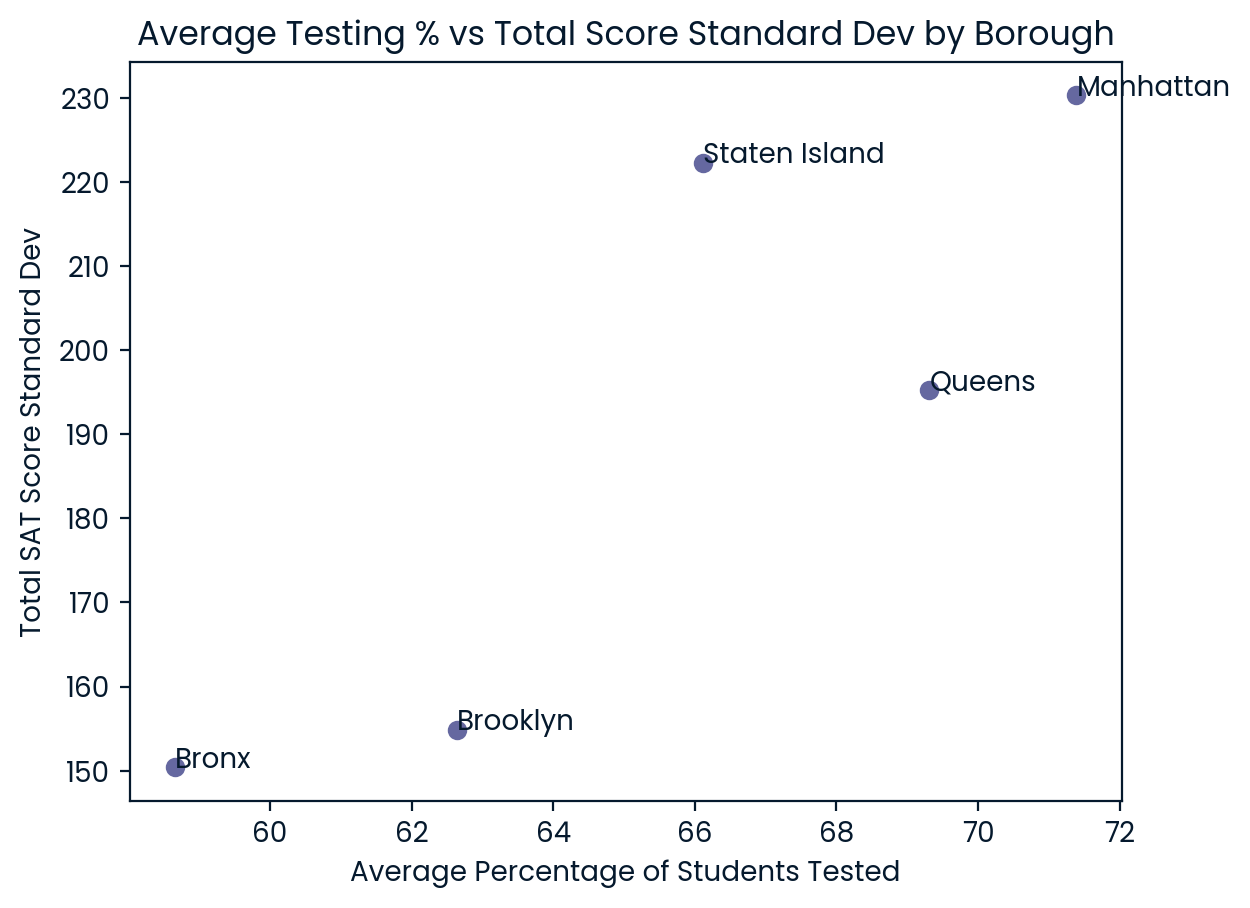

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

x = schools["percent_tested"]
y = schools["total_SAT"]

boroughs = schools['borough'].astype('category')
codes = boroughs.cat.codes
unique_boroughs = boroughs.cat.categories
colors = plt.cm.turbo(range(len(unique_boroughs)))

total_score_vs_percentage = plt.scatter(x, y, c=codes, cmap='turbo', alpha=.7)

plt.xlabel('Percent of Students Tested')
plt.ylabel('Average Total SAT Score')
plt.title('Percentage of Student Body Tested vs. Average Total Score')

handles = [mpatches.Patch(color=plt.cm.turbo(i / (len(unique_boroughs)-1)), label=borough) 
           for i, borough in enumerate(unique_boroughs)]
plt.legend(handles=handles, title="Borough")

plt.show()

total_by_borough = schools.pivot_table(values='total_SAT', index='borough', aggfunc=np.average)
avg_percentage_by_borough = schools.pivot_table(values='percent_tested', index='borough', aggfunc=np.nanmean)

total_by_borough_array = total_by_borough.values
avg_percentage_by_borough_array = avg_percentage_by_borough.values
standard_devs_array = standard_devs.values

borough_summary = {
    'Bronx':[total_by_borough_array[0][0], avg_percentage_by_borough_array[0][0], standard_devs_array[0][0]],
    'Brooklyn':[total_by_borough_array[1][0], avg_percentage_by_borough_array[1][0], standard_devs_array[1][0]],
    'Manhattan':[total_by_borough_array[2][0], avg_percentage_by_borough_array[2][0], standard_devs_array[2][0]],
    'Queens':[total_by_borough_array[3][0], avg_percentage_by_borough_array[3][0], standard_devs_array[3][0]],
    'Staten Island':[total_by_borough_array[4][0], avg_percentage_by_borough_array[4][0], standard_devs_array[4][0]]
}
borough_summary_df = pd.DataFrame(borough_summary)
borough_summary_renamed = borough_summary_df.rename(index={0:'avg_total_SAT', 1:'avg_percentage_tested', 2:'total_SAT_std_dev'})

plt.clf()

x1 = borough_summary_renamed.loc['avg_percentage_tested']
y1 = borough_summary_renamed.loc['avg_total_SAT']
y2 = borough_summary_renamed.loc['total_SAT_std_dev']

plt.scatter(x1, y1)
plt.xlabel('Average Percentage of Students Tested')
plt.ylabel('Average Total SAT Score')
plt.title('Average Testing % vs Average Total Score by Borough')

for i, text in enumerate(borough_summary_renamed.columns):
    plt.annotate(text, (x1[i], y1[i]))

plt.show()
plt.clf()

plt.scatter(x1, y2)
plt.xlabel('Average Percentage of Students Tested')
plt.ylabel('Total SAT Score Standard Dev')
plt.title('Average Testing % vs Total Score Standard Dev by Borough')

for i, text in enumerate(borough_summary_renamed.columns):
    plt.annotate(text, (x1[i], y2[i]))

plt.show()

In [7]:
total_by_borough = schools.pivot_table(values='total_SAT', index='borough', aggfunc=np.average)
avg_percentage_by_borough = schools.pivot_table(values='percent_tested', index='borough', aggfunc=np.nanmean)
print(total_by_borough)
print(avg_percentage_by_borough)

                 total_SAT
borough                   
Bronx          1202.724490
Brooklyn       1230.256881
Manhattan      1340.134831
Queens         1345.478261
Staten Island  1439.000000
               percent_tested
borough                      
Bronx               58.653763
Brooklyn            62.640385
Manhattan           71.390476
Queens              69.313846
Staten Island       66.111111


In [12]:
total_by_borough_array = total_by_borough.values
avg_percentage_by_borough_array = avg_percentage_by_borough.values
standard_devs_array = standard_devs.values

borough_summary = {
    'Bronx':[total_by_borough_array[0][0], avg_percentage_by_borough_array[0][0], standard_devs_array[0][0]],
    'Brooklyn':[total_by_borough_array[1][0], avg_percentage_by_borough_array[1][0], standard_devs_array[1][0]],
    'Manhattan':[total_by_borough_array[2][0], avg_percentage_by_borough_array[2][0], standard_devs_array[2][0]],
    'Queens':[total_by_borough_array[3][0], avg_percentage_by_borough_array[3][0], standard_devs_array[3][0]],
    'Staten Island':[total_by_borough_array[4][0], avg_percentage_by_borough_array[4][0], standard_devs_array[4][0]]
}
borough_summary_df = pd.DataFrame(borough_summary)
borough_summary_renamed = borough_summary_df.rename(index={0:'avg_total_SAT', 1:'avg_percentage_tested', 2:'total_SAT_std_dev'})
borough_summary_renamed.head

<bound method NDFrame.head of                              Bronx     Brooklyn  ...       Queens  Staten Island
avg_total_SAT          1202.724490  1230.256881  ...  1345.478261    1439.000000
avg_percentage_tested    58.653763    62.640385  ...    69.313846      66.111111
total_SAT_std_dev       150.393901   154.868427  ...   195.252899     222.303596

[3 rows x 5 columns]>

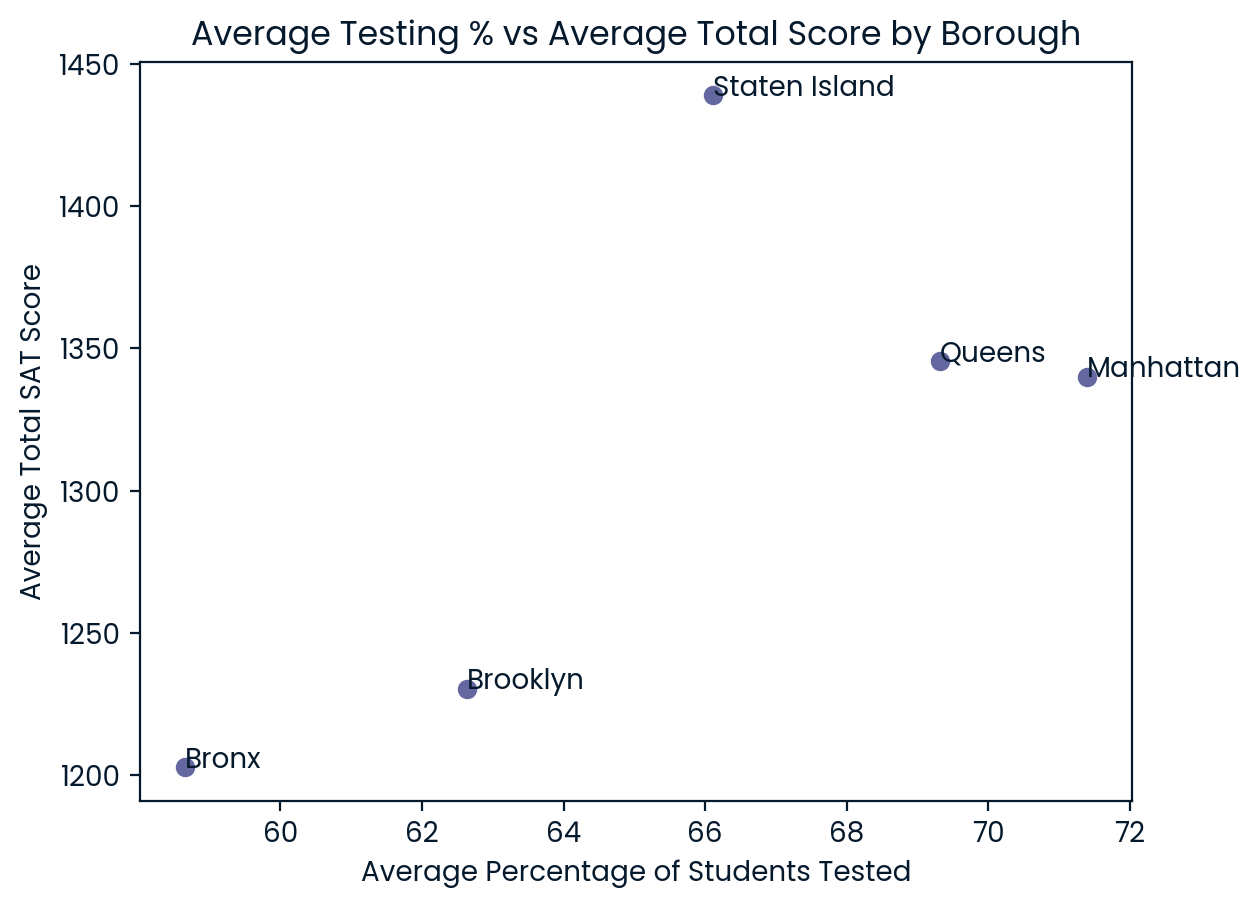

In [35]:
x1 = borough_summary_renamed.loc['avg_percentage_tested']
y1 = borough_summary_renamed.loc['avg_total_SAT']
y2 = borough_summary_renamed.loc['total_SAT_std_dev']

plt.scatter(x1, y1)
plt.xlabel('Average Percentage of Students Tested')
plt.ylabel('Average Total SAT Score')
plt.title('Average Testing % vs Average Total Score by Borough')

for i, text in enumerate(borough_summary_renamed.columns):
    plt.annotate(text, (x1[i], y1[i]))

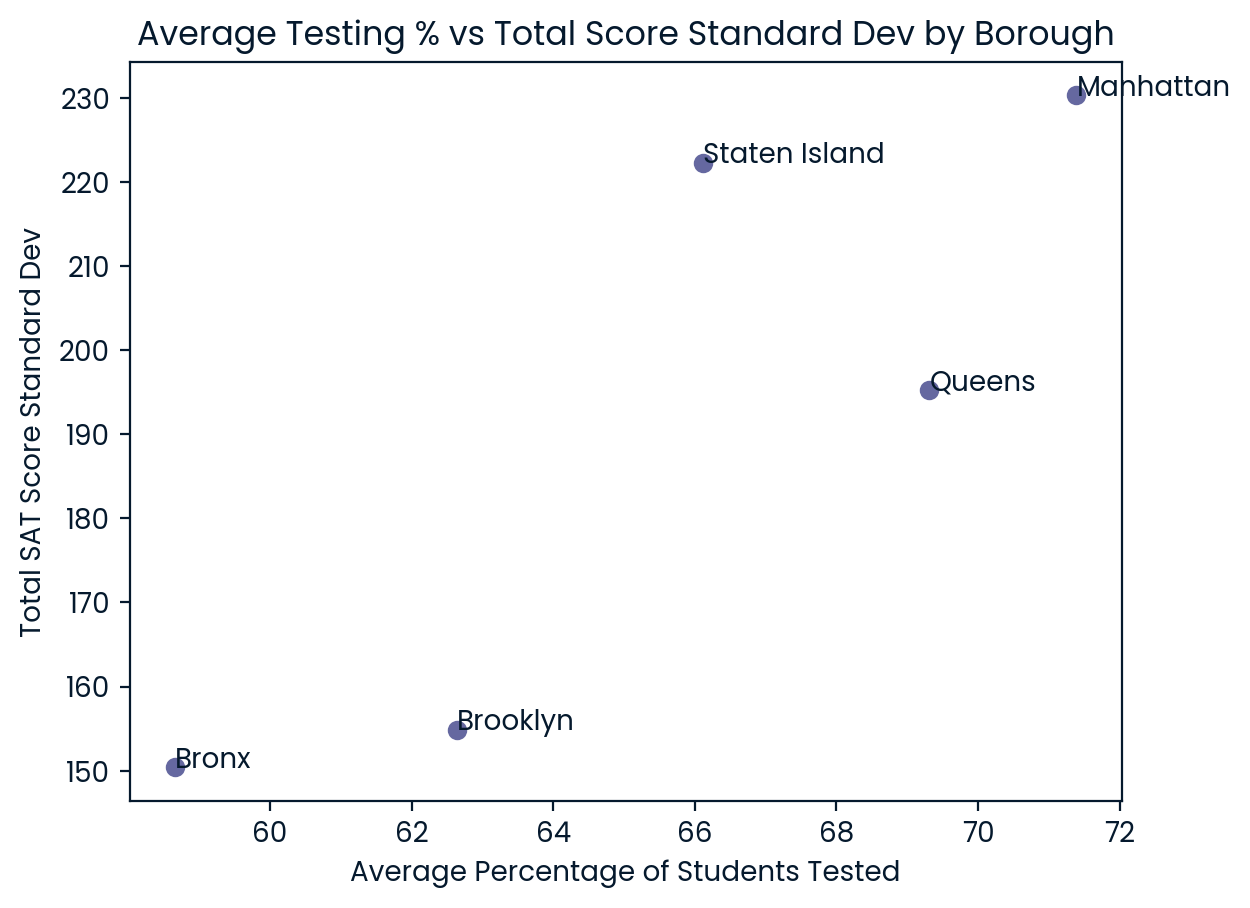

In [20]:
plt.scatter(x1, y2)
plt.xlabel('Average Percentage of Students Tested')
plt.ylabel('Total SAT Score Standard Dev')
plt.title('Average Testing % vs Total Score Standard Dev by Borough')

for i, text in enumerate(borough_summary_renamed.columns):
    plt.annotate(text, (x1[i], y2[i]))